In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

PROJECT_PATH = "/content/drive/MyDrive/cnn_project"

os.listdir(PROJECT_PATH + "/models")

['efficientnetb0_frozen.keras',
 'efficientnetb0_finetuned_final.keras',
 'cnn9_final.keras',
 'custom_cnn.keras',
 'mobilenet_finetuned.keras',
 'mobilenetv3_finetuned.keras']

In [15]:
EXERCISE_NAME = "cnn9_augmented_comparison"

RESULTS_PATH = PROJECT_PATH + f"/results/{EXERCISE_NAME}"
FIGURES_PATH = PROJECT_PATH + f"/figures/{EXERCISE_NAME}"

os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

Connecting Colab to Drive so models and outputs are saved. This is to avoid losing trained models and plots when Colab disconnects.


In [14]:
import os

PROJECT_PATH = "/content/drive/MyDrive/cnn_project"

folders = [
    "models",
    "checkpoints/efficientnetb0",
    "figures/efficientnetb0",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

## Importing Libraries

Importing TensorFlow, EfficientNetB0, plotting, and metrics tools:

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [ ]:
os.listdir(PROJECT_PATH + "/models")

['efficientnetb0_frozen.keras',
 'efficientnetb0_finetuned_final.keras',
 'cnn9_final.keras']

In [ ]:
cnn9_augmented = tf.keras.models.load_model(
    PROJECT_PATH + "/models/cnn9_final.keras"
)

cnn9_augmented.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,616 (1.08 MB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 189,078 (738.59 KB)

## Dataset Loading

The CIFAR-10 dataset contains 32×32 RGB images across 10 classes.

Loading CIFAR-10 directly from Keras:

In [13]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 355s 2us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


Visualising sample images to confirms the dataset and gives a useful image.

The Figure below illustrates CIFAR-10 sample images with labels.

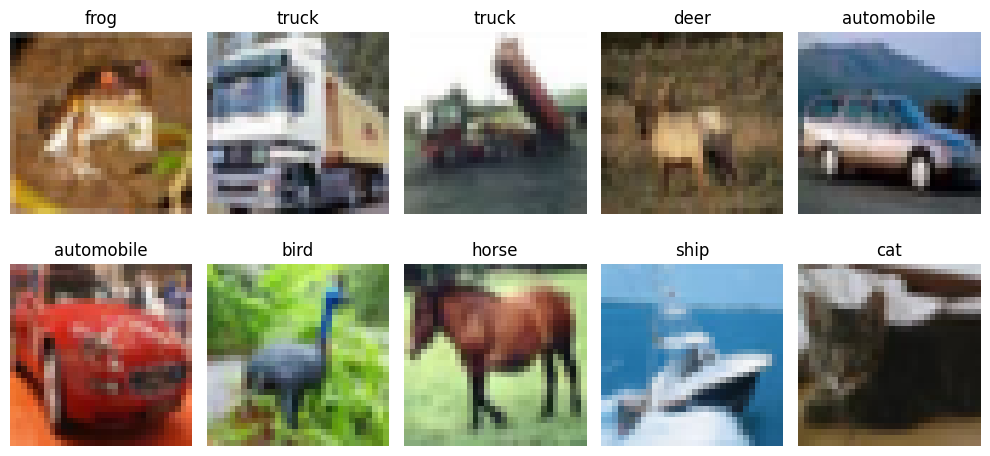

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "/figures/efficientnetb0/cifar10_samples.png", dpi=300)
plt.show()

Creating train/validation split; using part of the training data as validation data.

Validation data is used during training. Test data stays untouched until final model evaluation.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

## Preparing EfficientNetB0 input pipeline

Resizing CIFAR-10 images from 32×32 to 96×96 to build efficient TensorFlow datasets.

EfficientNetB0 works better with larger input images than CIFAR-10’s original 32×32. Using tf.data avoids storing all resized images in RAM.

No manual 0-1 normalisation being applied given that EfficientNet includes preprocessing internally.

In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 64

def resize_for_effnet(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

## Build of Frozen EfficientNetB0 Model

Loading EfficientNetB0 pretrained on ImageNet without its original classifier:

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
efficientnet_b0 = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

Here we reused the visual feature extractor from ImageNet and add our own CIFAR-10 classifier.

So, the Architecture is:
EfficientNetB0 base model frozen + GlobalAveragePooling2D + Dropout + Dense(10).

Capturing model summary:

In [ ]:
efficientnet_b0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Saving model summary to text:

In [ ]:
with open(PROJECT_PATH + "/results/efficientnetb0_summary.txt", "w") as f:
    efficientnet_b0.summary(print_fn=lambda x: f.write(x + "\n"))

## Compilation of Frozen Model

Compiling the model using Adam and sparse categorical cross-entropy (labels are integer class IDs, so sparse_categorical_crossentropy is appropriate):

Training setup:
Adam optimiser, learning rate 0.001, sparse categorical cross-entropy.

In [ ]:
efficientnet_b0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Adding Callbacks

Specifically, we'll be adding the following:

- Checkpointing (ModelCheckpoint)
- early stopping (EarlyStopping)
- adaptive learning-rate reduction (ReduceLROnPlateau)

These training controls prevent unnecessary training, save the best model, and reduce learning rate when validation loss plateaus.

In [ ]:
checkpoint_frozen = ModelCheckpoint(
    filepath=PROJECT_PATH + "/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

## Training of Frozen EfficientNetB0

Training only the classifier head, to adapt the final classifier to CIFAR-10 without changing the pretrained EfficientNetB0 weights.

In [ ]:
history_effnet_frozen = efficientnet_b0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_frozen, early_stop, reduce_lr]
)

Epoch 1/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6851 - loss: 0.9869
Epoch 1: val_loss improved from None to 0.47676, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 56ms/step - accuracy: 0.7752 - loss: 0.7040 - val_accuracy: 0.8415 - val_loss: 0.4768 - learning_rate: 0.0010
Epoch 2/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8285 - loss: 0.5196
Epoch 2: val_loss improved from 0.47676 to 0.43977, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8309 - loss: 0.5081 - val_accuracy: 0.8522 

Saving the model:

In [ ]:
efficientnet_b0.save(PROJECT_PATH + "/models/efficientnetb0_frozen.keras")

## Plotting and Saving of Frozen Learning Curves

In [ ]:
def plot_and_save_learning_curves(history, title, filename_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(PROJECT_PATH + f"/figures/efficientnetb0/{filename_prefix}_accuracy.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(PROJECT_PATH + f"/figures/efficientnetb0/{filename_prefix}_loss.png", dpi=300)
    plt.show()

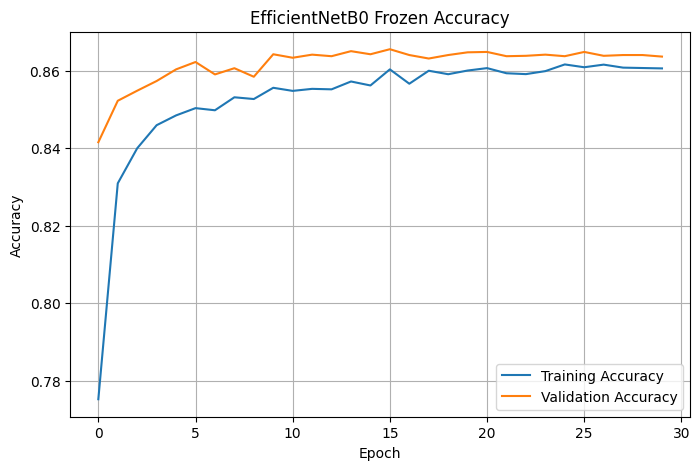

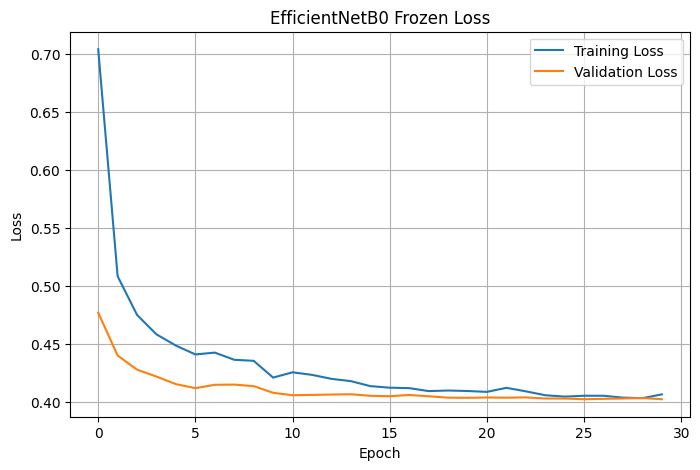

In [ ]:
plot_and_save_learning_curves(
    history_effnet_frozen,
    "EfficientNetB0 Frozen",
    "efficientnetb0_frozen"
)

From these plots, one observes that:

- Training accuracy rises quickly, then stabilises around 86%
- Validation accuracy is slightly higher, around 86–87%
- The curves are close together, so no obvious overfitting is seen
- The model plateaus after roughly 10–15 epochs
- Since the base model is frozen, this means the pretrained ImageNet features are already useful for CIFAR-10

The frozen EfficientNetB0 is performing well as a feature extractor. Fine-tuning the last layers may give a small additional improvement, but we should not expect a huge jump because performance is already quite stable.

Given the frozen EfficientNetB0 model's current performance, we will be fine-tuning gently by keeping the last 20 layers trainable and using the very low learning rate 1e-5. The frozen model is already stable, so fine-tuning should be conservative at this stage.

Fine-tuning last 20 layers (fine-tuning lets the model adapt to CIFAR-10, but keeping most layers frozen protects pretrained ImageNet knowledge):

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

Checking trainable layers (to confirm actually 20):

In [ ]:
trainable_count = sum([layer.trainable for layer in base_model.layers])
print("Trainable EfficientNetB0 layers:", trainable_count)

Trainable EfficientNetB0 layers: 20


## Recompilation (Very Low Learning Rate)

Recompiling with very low learning rate:

Fine-tuning changes the pretrained weights. A very low starting learning rate avoids damaging them. In other words the very slow starting learning rate of 1e-5 helps reduce the risk of catastrophic forgetting.

In [ ]:
efficientnet_b0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In order to protect the work done so far, we will save the frozen model before fine-tuning:

In [ ]:
efficientnet_b0.save(PROJECT_PATH + "/models/efficientnetb0_frozen.keras")

Checking that frozen model was indeed saved:

In [ ]:
import os
os.listdir(PROJECT_PATH + "/models")

['cnn9_final.keras', 'efficientnetb0_frozen.keras']

Training the model again with last 20 layers unfrozen:

**NOTE**: lowest learning rate allowed is 1e-7 if ReduceLROnPlateau keeps reducing it.

In [ ]:
checkpoint_finetuned = ModelCheckpoint(
    filepath=PROJECT_PATH + "/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop_finetune = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr_finetune = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history_effnet_finetuned = efficientnet_b0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_finetuned, early_stop_finetune, reduce_lr_finetune]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7578 - loss: 0.7678
Epoch 1: val_loss improved from None to 0.52899, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step - accuracy: 0.7773 - loss: 0.6995 - val_accuracy: 0.8315 - val_loss: 0.5290 - learning_rate: 1.0000e-05
Epoch 2/20
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8046 - loss: 0.6035
Epoch 2: val_loss improved from 0.52899 to 0.49270, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.8128 - loss: 0.5806 - val_a

In [ ]:
'efficientnet_b0' in globals(), 'history_effnet_finetuned' in globals()

(False, False)

Runtime disconnected at this point. Hence recreating data pipeline, loading frozen model, and rerunning fine-tuning.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

IMG_SIZE = 96
BATCH_SIZE = 64

def resize_for_effnet(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(resize_for_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 327s 2us/step


In [ ]:
print(type(X_test))
print(X_test.dtype)
print(X_test.shape)

<class 'numpy.ndarray'>
uint8
(10000, 32, 32, 3)


Reloading frozen model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/cnn_project"

In [ ]:
os.listdir(PROJECT_PATH)
os.listdir(PROJECT_PATH + "/models")
os.listdir(PROJECT_PATH + "/checkpoints/efficientnetb0")

['efficientnetb0_frozen_best.keras', 'efficientnetb0_finetuned_best.keras']

In [ ]:
efficientnet_b0 = tf.keras.models.load_model(
    PROJECT_PATH + "/checkpoints/efficientnetb0/efficientnetb0_frozen_best.keras"
)

In [ ]:
base_model = efficientnet_b0.layers[0]
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
efficientnet_b0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_effnet_finetuned = efficientnet_b0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_finetuned, early_stop_finetune, reduce_lr_finetune]
)

Epoch 1/20
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7596 - loss: 0.7545
Epoch 1: val_loss improved from None to 0.52794, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 64ms/step - accuracy: 0.7758 - loss: 0.6990 - val_accuracy: 0.8329 - val_loss: 0.5279 - learning_rate: 1.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8061 - loss: 0.5962
Epoch 2: val_loss improved from 0.52794 to 0.49133, saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/efficientnetb0/efficientnetb0_finetuned_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8127 - loss: 0.5734 - val_a

In [ ]:
efficientnet_b0.save(PROJECT_PATH + "/models/efficientnetb0_finetuned_final.keras")

In [10]:
import os

os.listdir(PROJECT_PATH + "/models")

['efficientnetb0_frozen.keras',
 'efficientnetb0_finetuned_final.keras',
 'cnn9_final.keras',
 'custom_cnn.keras',
 'mobilenet_finetuned.keras',
 'mobilenetv3_finetuned.keras']

In [ ]:
model_path = PROJECT_PATH + "/models/efficientnetb0_finetuned_final.keras"
print(model_path)
print(os.path.exists(model_path))

/content/drive/MyDrive/cnn_project/models/efficientnetb0_finetuned_final.keras
True


## Plotting and Saving Fine-Tuning Curves

Now potting the following Figures:

- EfficientNetB0 fine-tuned accuracy curve.
- EfficientNetB0 fine-tuned loss curve.

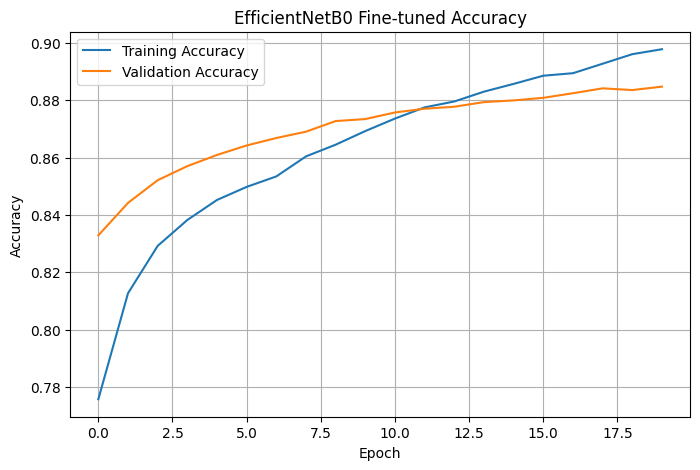

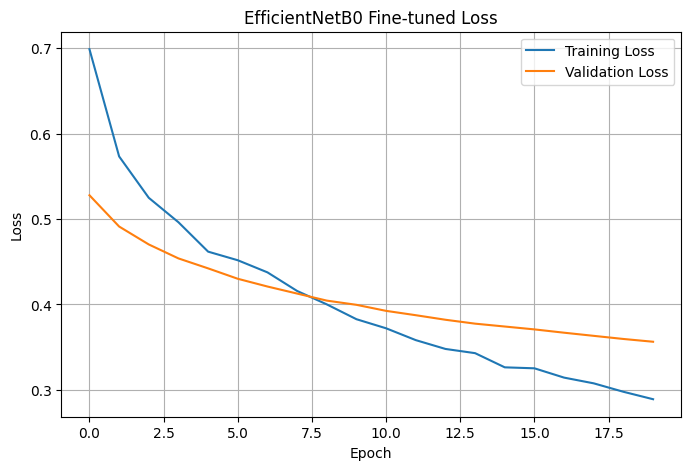

In [ ]:
plot_and_save_learning_curves(
    history_effnet_finetuned,
    "EfficientNetB0 Fine-tuned",
    "efficientnetb0_finetuned"
)

Fine-tuning improved the model.

Compared with the frozen model:

- Frozen model plateaued around 86–87% validation accuracy
- Fine-tuned model reaches around 88–89% validation accuracy
- Training accuracy keeps rising to about 90%
- Validation accuracy also improves, but more slowly
- There is a small gap between training and validation accuracy, so slight overfitting may be starting
- Overall, fine-tuning the last 20 layers helped the model adapt better to CIFAR-1

After fine-tuning the last 20 layers of EfficientNetB0, validation accuracy improved compared with the frozen model. The frozen model had already performed well as a feature extractor, but fine-tuning allowed the model to adapt more specifically to CIFAR-10. The training accuracy increased slightly faster than validation accuracy, suggesting mild overfitting, but the validation curve still improved overall, so fine-tuning was beneficial.



## Evaluation of EfficientNetB0

We will now compute accuracy, precision, recall, F1, classification report, and confusion matrix for both validation and testing.

To this end, the following function is defined:

In [7]:
def evaluate_model_on_dataset(model, dataset, y_true, model_name, filename_prefix):
    y_probs = model.predict(dataset)
    y_pred = np.argmax(y_probs, axis=1)
    y_true_flat = y_true.reshape(-1)

    accuracy = accuracy_score(y_true_flat, y_pred)
    precision = precision_score(y_true_flat, y_pred, average="weighted")
    recall = recall_score(y_true_flat, y_pred, average="weighted")
    f1 = f1_score(y_true_flat, y_pred, average="weighted")

    print(model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    report = classification_report(
        y_true_flat,
        y_pred,
        target_names=class_names
    )

    print("\nClassification Report:")
    print(report)

    with open(PROJECT_PATH + f"/results/{filename_prefix}_classification_report.txt", "w") as f:
        f.write(report)

    cm = confusion_matrix(y_true_flat, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(model_name + " Confusion Matrix")
    plt.tight_layout()
    plt.savefig(PROJECT_PATH + f"/figures/efficientnetb0/{filename_prefix}_confusion_matrix.png", dpi=300)
    plt.show()

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

    return metrics, y_pred

In [9]:
efficientnetb0_finetuned = efficientnet_b0

NameError: name 'efficientnet_b0' is not defined

###Evaluation on Validation

In [8]:
effnet_val_metrics, y_val_pred_effnet = evaluate_model_on_dataset(
    efficientnetb0_finetuned,
    val_ds,
    y_val,
    "EfficientNetB0 Fine-tuned Validation",
    "efficientnetb0_val"
)

NameError: name 'efficientnetb0_finetuned' is not defined

### EfficientNetB0 Fine-tuned Model - Validation Evaluation Interpretation

The fine-tuned EfficientNetB0 model achieved an overall accuracy of 88%, with macro and weighted averages of 0.88 for precision, recall and F1-score. Since CIFAR-10 is a balanced dataset, with 1,000 samples per class in the evaluation set, the macro and weighted averages are very similar.

Overall, the model performs well across most classes. The strongest classes are automobile, ship, truck, frog and horse, all of which achieved high F1-scores (balance between precision and recall). Automobile achieved an F1-score of 0.94, ship achieved 0.93, truck achieved 0.92, frog achieved 0.91, and horse achieved 0.90. This suggests that the model is able to identify these classes with relatively high consistency.

The weakest class is cat, with precision of 0.79, recall of 0.78 and F1-score of 0.79. This means the model struggles more with cat images than with the other classes. In practical terms, the model sometimes predicts cat incorrectly, and it also misses some true cat images.

The confusion matrix confirms this. The largest confusion pair is between cats and dogs: 87 cat images were predicted as dog, and 87 dog images were predicted as cat. This is understandable because cats and dogs can share similar visual features such as fur, body shape, legs, face structure and backgrounds, especially in small 32×32 CIFAR-10 images.

Other relevant confusion pairs include automobile and truck, airplane and ship, deer and horse, and bird with frog or cat. These errors are also reasonable because some of these classes share visual or contextual features. For example, automobiles and trucks often appear in similar road contexts, while airplanes and ships may share blue sky or water-like backgrounds.

The diagonal values in the confusion matrix are high for most classes, which shows that the model is generally making correct predictions. The off-diagonal values reveal where the model is confused. These class-level errors are important because they show that the model’s overall accuracy does not tell the full story; the confusion matrix helps identify which categories are more difficult.

In summary, the fine-tuned EfficientNetB0 model generalises well overall, but still shows class-specific weaknesses, especially for visually similar animal classes such as cat and dog. This is a useful result for comparison against the custom CNN and the other transfer learning models.

###Evaluation on Test:

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
EfficientNetB0 Fine-tuned Test
Accuracy: 0.8848
Precision: 0.8846910585100232
Recall: 0.8848
F1: 0.8846464649317791

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.89      0.89      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.89      0.85      0.87      1000
         cat       0.79      0.77      0.78      1000
        deer       0.86      0.88      0.87      1000
         dog       0.83      0.83      0.83      1000
        frog       0.89      0.92      0.91      1000
       horse       0.92      0.91      0.92      1000
        ship       0.92      0.93      0.92      1000
       truck       0.92      0.93      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



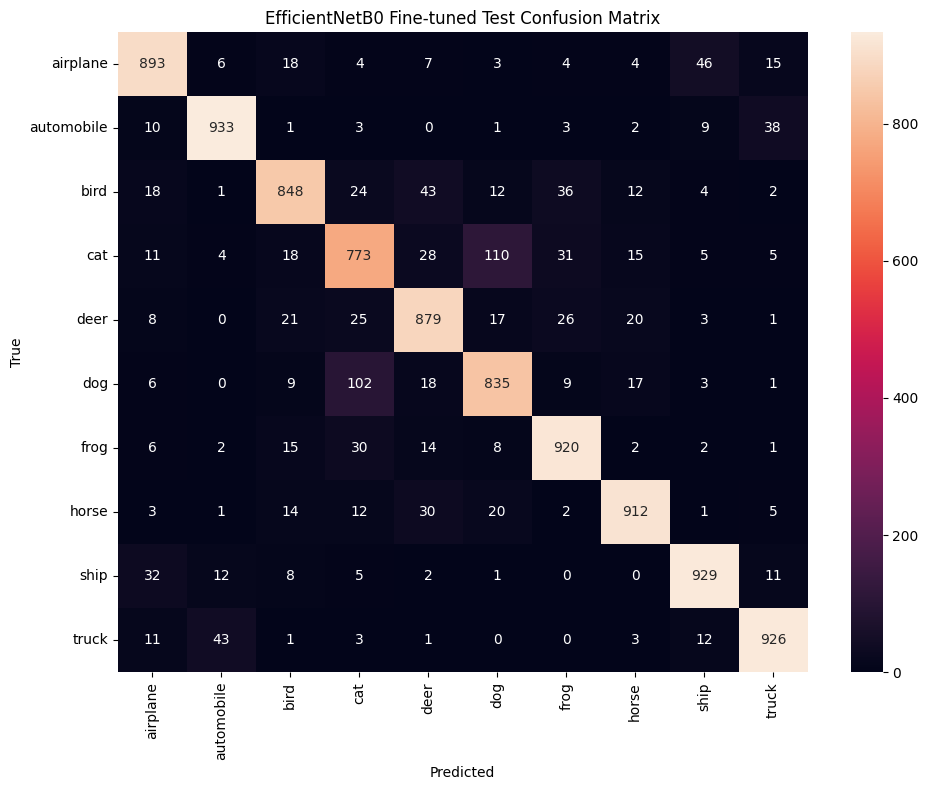

In [ ]:
effnet_test_metrics, y_test_pred_effnet = evaluate_model_on_dataset(
    efficientnetb0_finetuned,
    test_ds,
    y_test,
    "EfficientNetB0 Fine-tuned Test",
    "efficientnetb0_test"
)

### EfficientNetB0 Fine-tuned Model - Test Evaluation Interpretation

The fine-tuned EfficientNetB0 model achieved an overall test accuracy of 88%. The macro average and weighted average for precision, recall and F1-score are also 0.88. Since CIFAR-10 is a balanced dataset with 1,000 images per class in the test set, the macro and weighted averages are almost identical.

The test results are consistent with the validation results, which also showed around 88% accuracy. This suggests that the model generalises well and that the validation performance was a reliable estimate of final test performance.

The strongest performing classes are automobile, frog, horse, ship and truck. Automobile achieved an F1-score of 0.93, while frog, horse, ship and truck all achieved F1-scores between 0.91 and 0.92. This indicates that the model can identify these classes with strong consistency.

The weakest classes are cat, dog and bird. Cat is the most challenging class, with precision of 0.79, recall of 0.77 and F1-score of 0.78. This means the model both misclassifies some non-cat images as cats and also misses some true cat images. Dog also performs lower than most other classes, with an F1-score of 0.83.

The confusion matrix confirms the main class-level weaknesses. The largest confusion pair is between cats and dogs: 110 cat images were predicted as dog, and 102 dog images were predicted as cat. This is understandable because cats and dogs share visual features such as fur, body shape, legs, facial structure and similar backgrounds, especially in small CIFAR-10 images.

Other relevant confusion pairs include airplane and ship, automobile and truck, bird and deer, and bird and frog. These errors are reasonable because these classes can share visual or contextual similarities. For example, automobiles and trucks often appear in similar road scenes, while airplanes and ships may share blue or open backgrounds.

Overall, the fine-tuned EfficientNetB0 model performs well on the CIFAR-10 test set. The model shows strong generalisation from validation to test data, with only mild class-specific weaknesses. The main limitation is not overall accuracy, but confusion between visually similar classes, especially cat and dog.

## Saving EfficientNetB0 Results Table

Next, we print the EfficientNetB0 validation and test metrics. This will facilitate further comparison with DenseNet121, MobileNet, and the best custom CNN (CNN9).

In [ ]:
effnet_results_df = pd.DataFrame([
    effnet_val_metrics,
    effnet_test_metrics
])

effnet_results_df.to_csv(
    PROJECT_PATH + "/results/efficientnetb0_results.csv",
    index=False
)

effnet_results_df

,Model,Accuracy,Precision,Recall,F1
0,EfficientNetB0 Fine-tuned Validation,0.8847,0.884552,0.8847,0.884528
1,EfficientNetB0 Fine-tuned Test,0.8848,0.884691,0.8848,0.884646


## Loading and Evaluation of Best Custom CNN

We will now load our best custom CNN and compare it against EfficientNetB0.

In [16]:
cnn9_augmented = tf.keras.models.load_model(
    PROJECT_PATH + "/models/cnn9_final.keras"
)

cnn9_augmented.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,616 (1.08 MB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 189,078 (738.59 KB)

## Preparing Test Data for CNN9 Augmented

Given that CNN9 was trained on normalised 32x32 CIFAR-10 images:

In [17]:
X_test_cnn = X_test.astype("float32") / 255.0
y_true_test = y_test.reshape(-1)

In [ ]:
print(type(X_test_cnn))
print(X_test_cnn.dtype)
print(X_test_cnn.shape)

<class 'numpy.ndarray'>
float32
(10000, 32, 32, 3)


##Evaluation of CNN9_Augmented



In [18]:
y_probs_cnn9_augmented = cnn9_augmented.predict(X_test_cnn)
y_pred_cnn9_augmented = np.argmax(y_probs_cnn9_augmented, axis=1)

cnn9_augmented_metrics = {
    "Model": "CNN9 Augmented Final",
    "Accuracy": accuracy_score(y_true_test, y_pred_cnn9_augmented),
    "Precision": precision_score(y_true_test, y_pred_cnn9_augmented, average="weighted"),
    "Recall": recall_score(y_true_test, y_pred_cnn9_augmented, average="weighted"),
    "F1": f1_score(y_true_test, y_pred_cnn9_augmented, average="weighted")
}

cnn9_augmented_metrics

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


{'Model': 'CNN9 Augmented Final',
 'Accuracy': 0.7324,
 'Precision': 0.7379552395345248,
 'Recall': 0.7324,
 'F1': 0.7272208868867802}

In [ ]:
import os

EXERCISE_NAME = "cnn9_augmented_comparison"
RESULTS_PATH = PROJECT_PATH + f"/results/{EXERCISE_NAME}"

os.makedirs(RESULTS_PATH, exist_ok=True)

In [ ]:
report_cnn9_augmented = classification_report(
    y_true_test,
    y_pred_cnn9_augmented,
    target_names=class_names
)

print(report_cnn9_augmented)

with open(RESULTS_PATH + "/cnn9_augmented_classification_report.txt", "w") as f:
    f.write(report_cnn9_augmented)

              precision    recall  f1-score   support

    airplane       0.64      0.85      0.73      1000
  automobile       0.86      0.88      0.87      1000
        bird       0.80      0.47      0.59      1000
         cat       0.59      0.54      0.56      1000
        deer       0.77      0.62      0.69      1000
         dog       0.67      0.66      0.67      1000
        frog       0.69      0.85      0.76      1000
       horse       0.77      0.73      0.75      1000
        ship       0.84      0.84      0.84      1000
       truck       0.75      0.89      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



In [ ]:
import os

EXERCISE_NAME = "cnn9_augmented_comparison"
FIGURES_PATH = PROJECT_PATH + f"/figures/{EXERCISE_NAME}"

os.makedirs(FIGURES_PATH, exist_ok=True)

In [6]:
cm_cnn9_augmented = confusion_matrix(
    y_true_test,
    y_pred_cnn9_augmented
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnn9_augmented,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN9 Augmented Final Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_PATH + "/cnn9_augmented_confusion_matrix.png", dpi=300)
plt.show()

NameError: name 'y_true_test' is not defined

Loading existing EfficientNetB0 results

In [19]:
effnet_results_df = pd.read_csv(
    PROJECT_PATH + "/results/efficientnetb0_results.csv"
)

effnet_results_df

,Model,Accuracy,Precision,Recall,F1
0,EfficientNetB0 Fine-tuned Validation,0.8847,0.884552,0.8847,0.884528
1,EfficientNetB0 Fine-tuned Test,0.8848,0.884691,0.8848,0.884646


In [20]:
effnet_test_row = effnet_results_df[
    effnet_results_df["Model"].str.contains("Test", case=False, na=False)
].iloc[0]

effnet_test_metrics = {
    "Model": "EfficientNetB0 Fine-tuned",
    "Accuracy": effnet_test_row["Accuracy"],
    "Precision": effnet_test_row["Precision"],
    "Recall": effnet_test_row["Recall"],
    "F1": effnet_test_row["F1"]
}

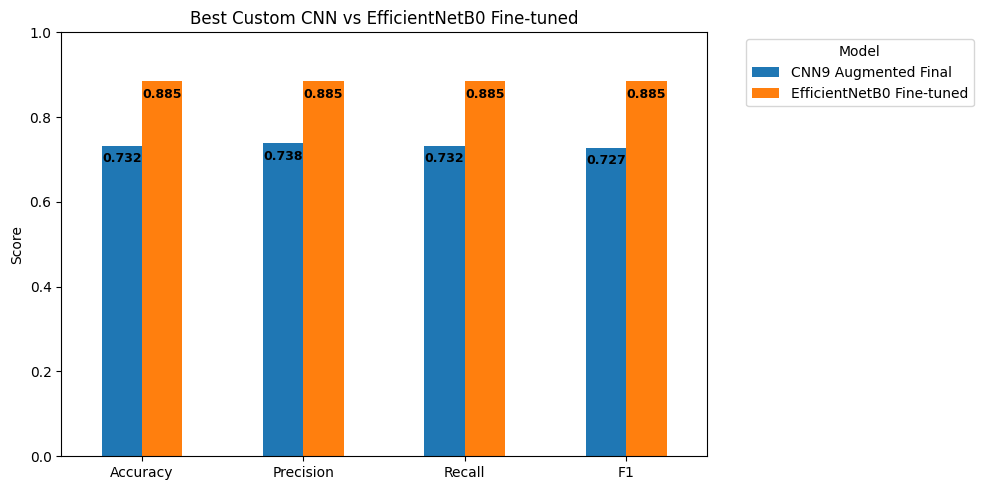

In [23]:
metrics_plot_df = pd.DataFrame([
    cnn9_augmented_metrics,
    effnet_test_metrics
])

metrics_plot_df = metrics_plot_df.set_index("Model")

ax = metrics_plot_df[["Accuracy", "Precision", "Recall", "F1"]].T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Best Custom CNN vs EfficientNetB0 Fine-tuned")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Add metric values near the top of each bar, inside the bar
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height - 0.015,          # close to top, still inside
            f"{height:.3f}",
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_PATH + "/best_custom_cnn_vs_efficientnetb0_metrics_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison Table: CNN9 Augmented vs EfficientNetB0 (Fine-Tuned)

In [ ]:
comparison_df = pd.DataFrame([
    cnn9_augmented_metrics,
    effnet_test_metrics
])

comparison_df.to_csv(
    RESULTS_PATH + "/cnn9_augmented_vs_efficientnetb0_finetuned.csv",
    index=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,CNN9 Augmented Final,0.7324,0.737955,0.7324,0.727221
1,EfficientNetB0 Fine-tuned,0.8848,0.884691,0.8848,0.884646


## Final Models Comparison (Baseline and Transfer Learning)

Best Custom CNN (CNN9) vs EfficientNetB0 vs DenseNet121 vs MobileNet.

In [5]:
cnn9_augmented_metrics

NameError: name 'cnn9_augmented_metrics' is not defined

In [ ]:
group_comparison_df = pd.DataFrame([
    cnn9_augmented_metrics,
    effnet_test_metrics,
    {"Model": "DenseNet121 Fine-tuned", "Accuracy": None, "Precision": None, "Recall": None, "F1": None},
    {"Model": "MobileNet Fine-tuned", "Accuracy": None, "Precision": None, "Recall": None, "F1": None}
])

group_comparison_df.to_csv(
    RESULTS_PATH + "/group_comparison_with_cnn9_augmented.csv",
    index=False
)

group_comparison_df

,Model,Accuracy,Precision,Recall,F1
0,CNN9 Augmented Final,0.7324,0.737955,0.7324,0.727221
1,EfficientNetB0 Fine-tuned,0.8848,0.884691,0.8848,0.884646
2,DenseNet121 Fine-tuned,NaN,NaN,NaN,NaN
3,MobileNet Fine-tuned,NaN,NaN,NaN,NaN


In [ ]:
group_comparison_df.to_csv(
    RESULTS_PATH + "/group_comparison_cnn9_augmented_vs_transfer_models.csv",
    index=False
)

In [ ]:
print(os.listdir(RESULTS_PATH))
print(os.listdir(FIGURES_PATH))

['cnn9_augmented_classification_report.txt', 'cnn9_augmented_vs_efficientnetb0_finetuned.csv', 'group_comparison_with_cnn9_augmented.csv', 'group_comparison_cnn9_augmented_vs_transfer_models.csv']
['cnn9_augmented_confusion_matrix.png']


### Comparison Setup

cnn9_final.keras was selected as the best custom CNN from our architecture experiments. It was trained from scratch on normalised 32×32 CIFAR-10 images.

EfficientNetB0 Fine-tuned was selected as one of the transfer learning models. It used ImageNet pretrained weights, resized CIFAR-10 images to 96×96, and fine-tuned only the last 20 layers with a low learning rate of 1e-5.

The comparison uses the same CIFAR-10 test set and the same evaluation metrics: accuracy, precision, recall and F1-score.

## Inspection of Common Confusion Pairs

Next, we will list certain visual examples of misclassified CIFAR-10 images for common confusion pairs.

These give an idea of model weaknesses.

In [ ]:
def show_confusion_examples(X_original, y_true, y_pred, true_class, pred_class, n=5):
    y_true_flat = y_true.reshape(-1)

    indexes = np.where(
        (y_true_flat == true_class) & (y_pred == pred_class)
    )[0]

    if len(indexes) == 0:
        print(f"No examples found: true {class_names[true_class]} predicted as {class_names[pred_class]}")
        return

    plt.figure(figsize=(12, 3))

    for i in range(min(n, len(indexes))):
        idx = indexes[i]
        plt.subplot(1, n, i + 1)
        plt.imshow(X_original[idx])
        plt.title(f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(
        PROJECT_PATH + f"/figures/efficientnetb0/confusion_examples_{class_names[true_class]}_as_{class_names[pred_class]}.png",
        dpi=300
    )
    plt.show()

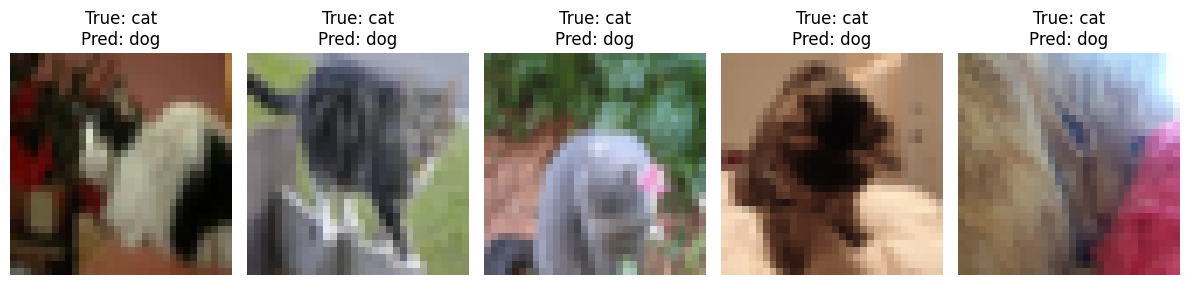

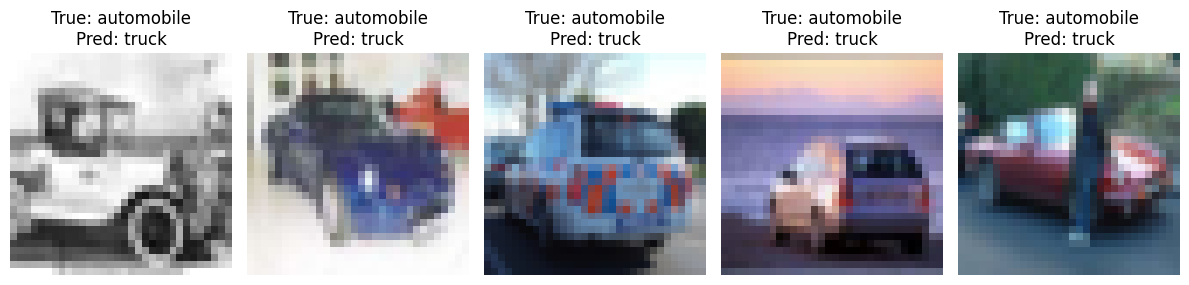

In [ ]:
# cat predicted as dog
show_confusion_examples(X_test, y_test, y_test_pred_effnet, true_class=3, pred_class=5)

# automobile predicted as truck
show_confusion_examples(X_test, y_test, y_test_pred_effnet, true_class=1, pred_class=9)

EfficientNetB0 preprocessing:
- CIFAR-10 images were resized from 32×32×3 to 96×96×3.
- Images were kept in the 0–255 range because EfficientNetB0 includes preprocessing internally.

Frozen model:
- The EfficientNetB0 base was frozen.
- Only the custom classification head was trained.
- This tested how useful the pretrained ImageNet features were without changing the base model.

Fine-tuning:
- The last 20 layers were unfrozen.
- A very low learning rate was used.
- This allowed limited adaptation to CIFAR-10 while reducing the risk of damaging pretrained weights.

Evaluation:
- The model was evaluated using accuracy, precision, recall, F1-score and confusion matrix.
- Results were compared against the best custom CNN and will be compared with DenseNet121 and MobileNet from the group.

In [ ]:
import os

os.listdir(PROJECT_PATH + "/models")
os.listdir(PROJECT_PATH + "/figures/efficientnetb0")
os.listdir(PROJECT_PATH + "/results")

['efficientnetb0_summary.txt',
 'efficientnetb0_val_classification_report.txt',
 'efficientnetb0_test_classification_report.txt',
 'efficientnetb0_results.csv',
 'cnn9_vs_efficientnetb0_finetuned_comparison.csv',
 'cnn9_vs_efficientnetb0_finetuned_comparison.gsheet',
 'cnn9_vs_efficientnetb0_finetuned_comparison (1).gsheet',
 'group_model_comparison_template.csv',
 'efficientnetb0_results.gsheet',
 'cnn9_vs_efficientnetb0_finetuned_comparison (2).gsheet']

In [ ]:
print(PROJECT_PATH)
print(os.listdir(PROJECT_PATH + "/figures"))
print(os.listdir(PROJECT_PATH + "/figures/efficientnetb0"))

/content/drive/MyDrive/cnn_project
['efficientnetb0']
['cifar10_samples.png', 'efficientnetb0_frozen_accuracy.png', 'efficientnetb0_frozen_loss.png', 'efficientnetb0_finetuned_accuracy.png', 'efficientnetb0_finetuned_loss.png', 'efficientnetb0_val_confusion_matrix.png', 'efficientnetb0_test_confusion_matrix.png', 'confusion_examples_cat_as_dog.png', 'confusion_examples_automobile_as_truck.png']


In [4]:
cnn9_augmented_metrics
effnet_test_metrics

NameError: name 'cnn9_augmented_metrics' is not defined